# EDA and Data Preprocessing On Heat Dataset 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA and Data Cleaning

In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

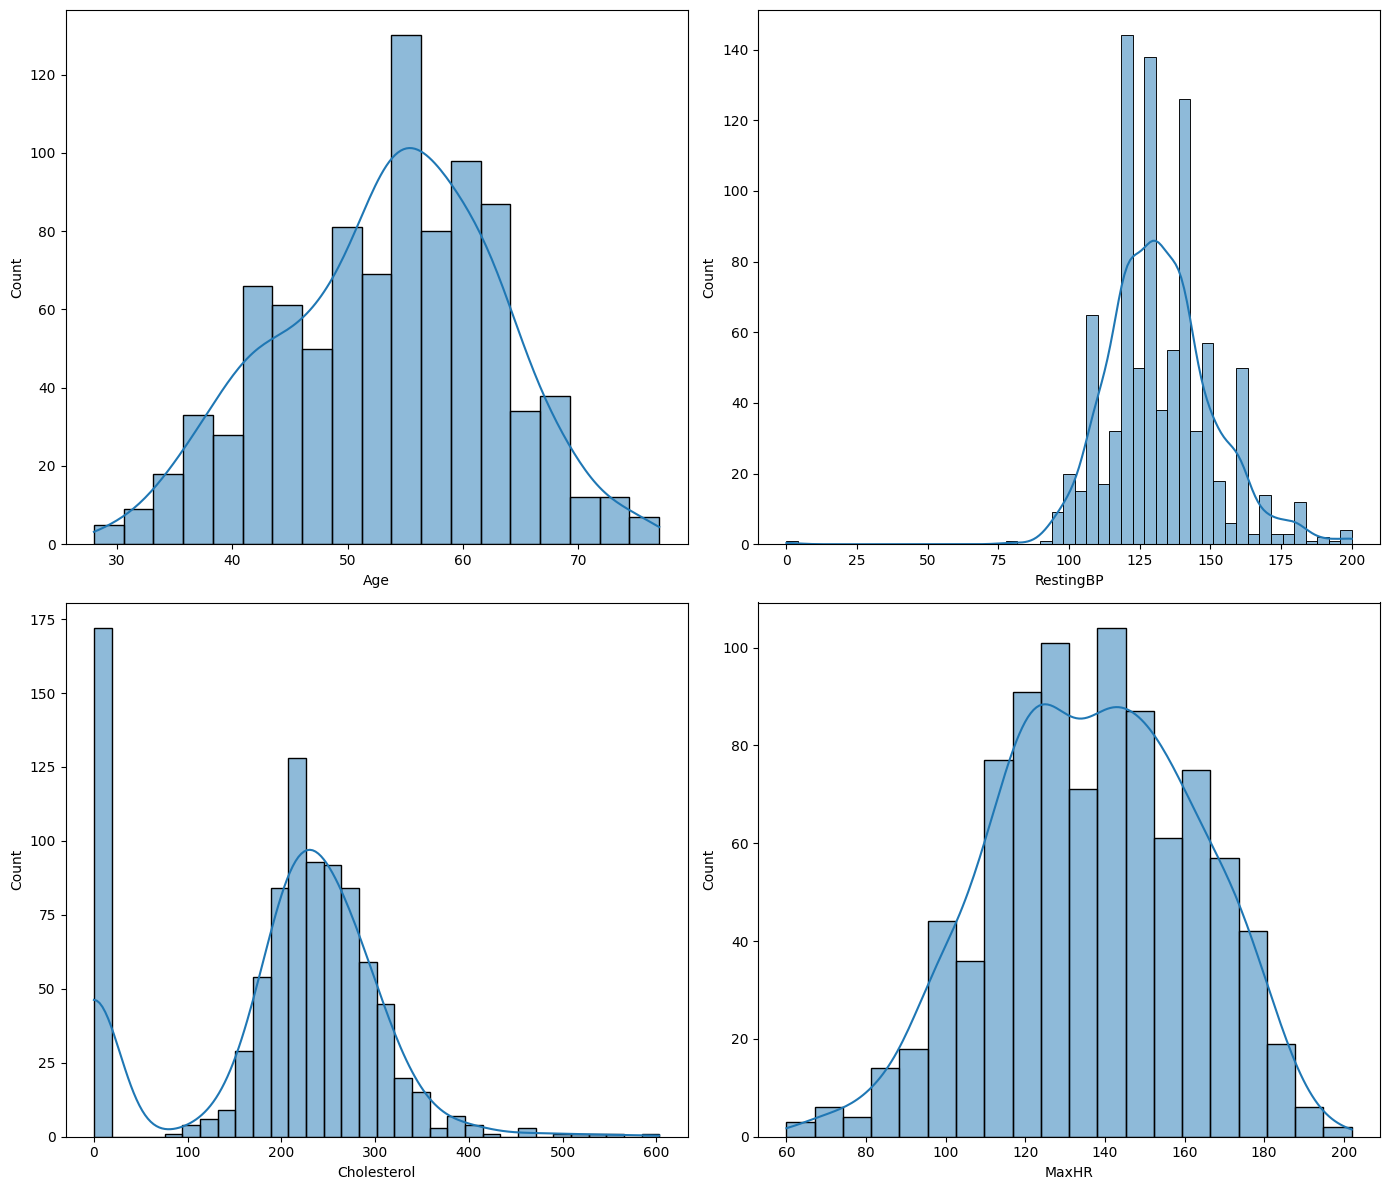

In [9]:
fig,axis = plt.subplots(2,2,figsize=(14,12))
axis = axis.flatten()
col = ['Age','RestingBP','Cholesterol','MaxHR']
for i, cols in enumerate(col):
    sns.histplot(df[cols], ax=axis[i], kde=True)
plt.tight_layout()

In [10]:
ch_mean = df.loc[df['Cholesterol' ] !=0,'Cholesterol'].mean()    # I find the inconsistentency in the cholesterol data by 0

In [11]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)       # which is not possible so i replace this by their mean.
df['Cholesterol'] = df['Cholesterol'].round(2)

In [12]:
resting_bp = df.loc[df['RestingBP'] !=0,'RestingBP'].mean()   # Similary in restingBP 0 is can't possible(by google search).

In [13]:
df['RestingBP'] = df['RestingBP'].replace(0,resting_bp)      # So i replace this by their mean.
df['RestingBP'] = df['RestingBP'].round(2)

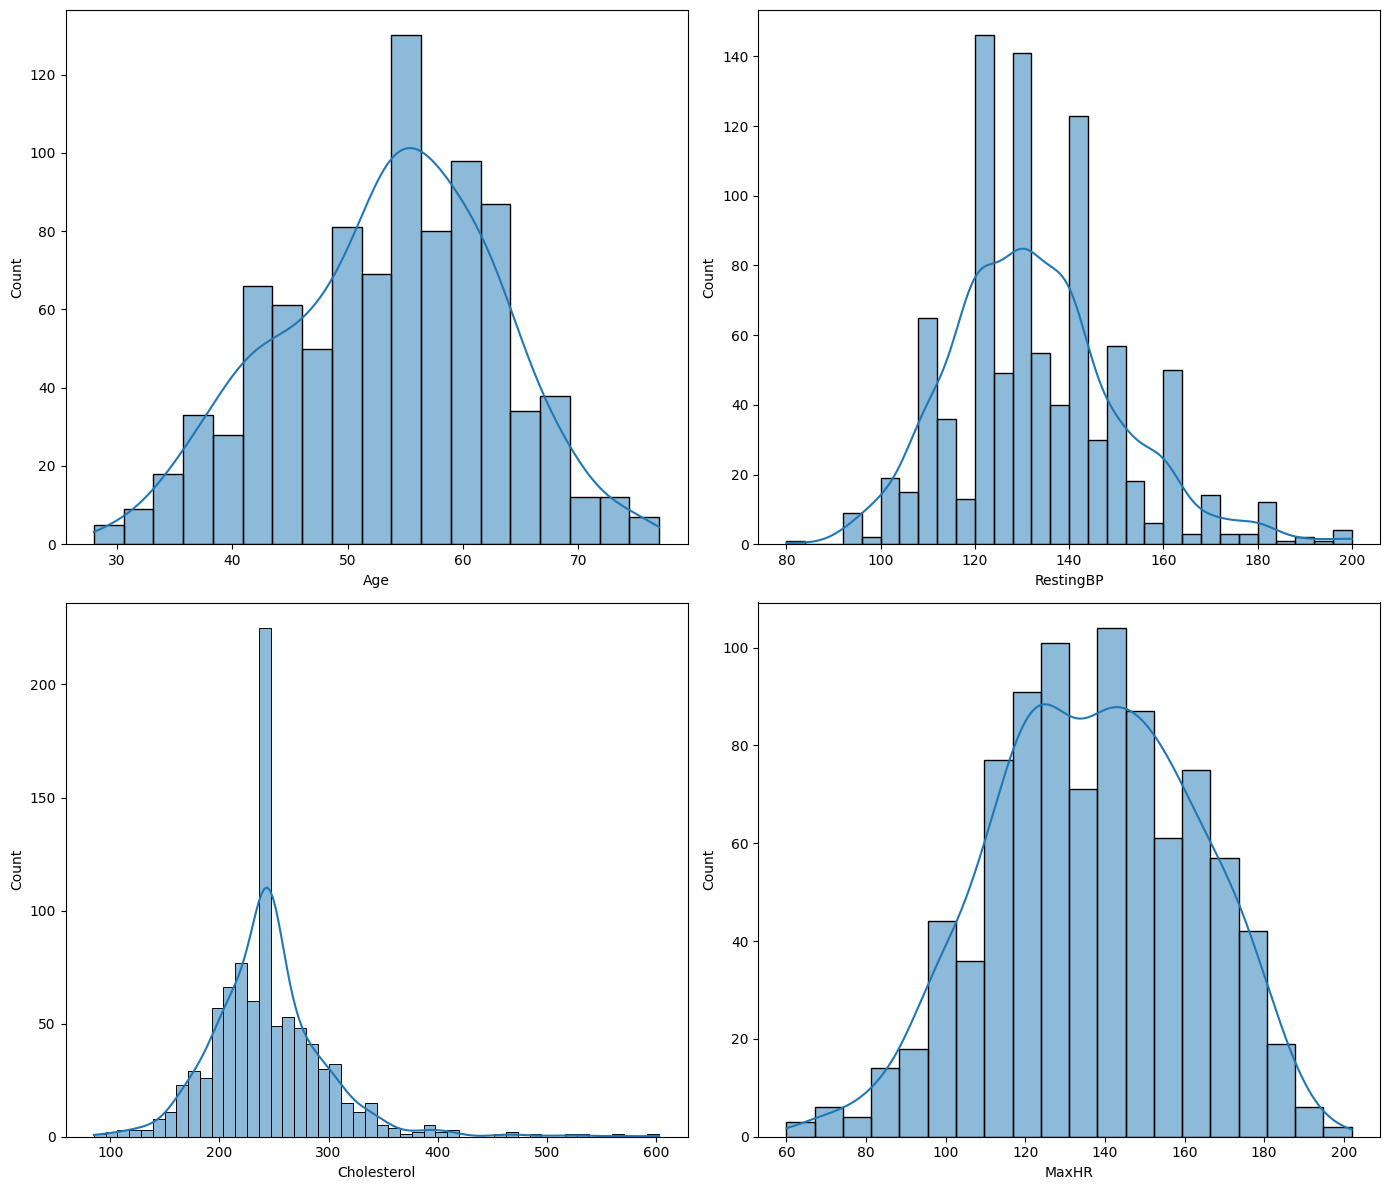

In [14]:
fig,axis = plt.subplots(2,2,figsize=(14,12))
axis = axis.flatten()
col = ['Age','RestingBP','Cholesterol','MaxHR']
for i, cols in enumerate(col):
    sns.histplot(df[cols], ax=axis[i], kde=True)
plt.tight_layout()

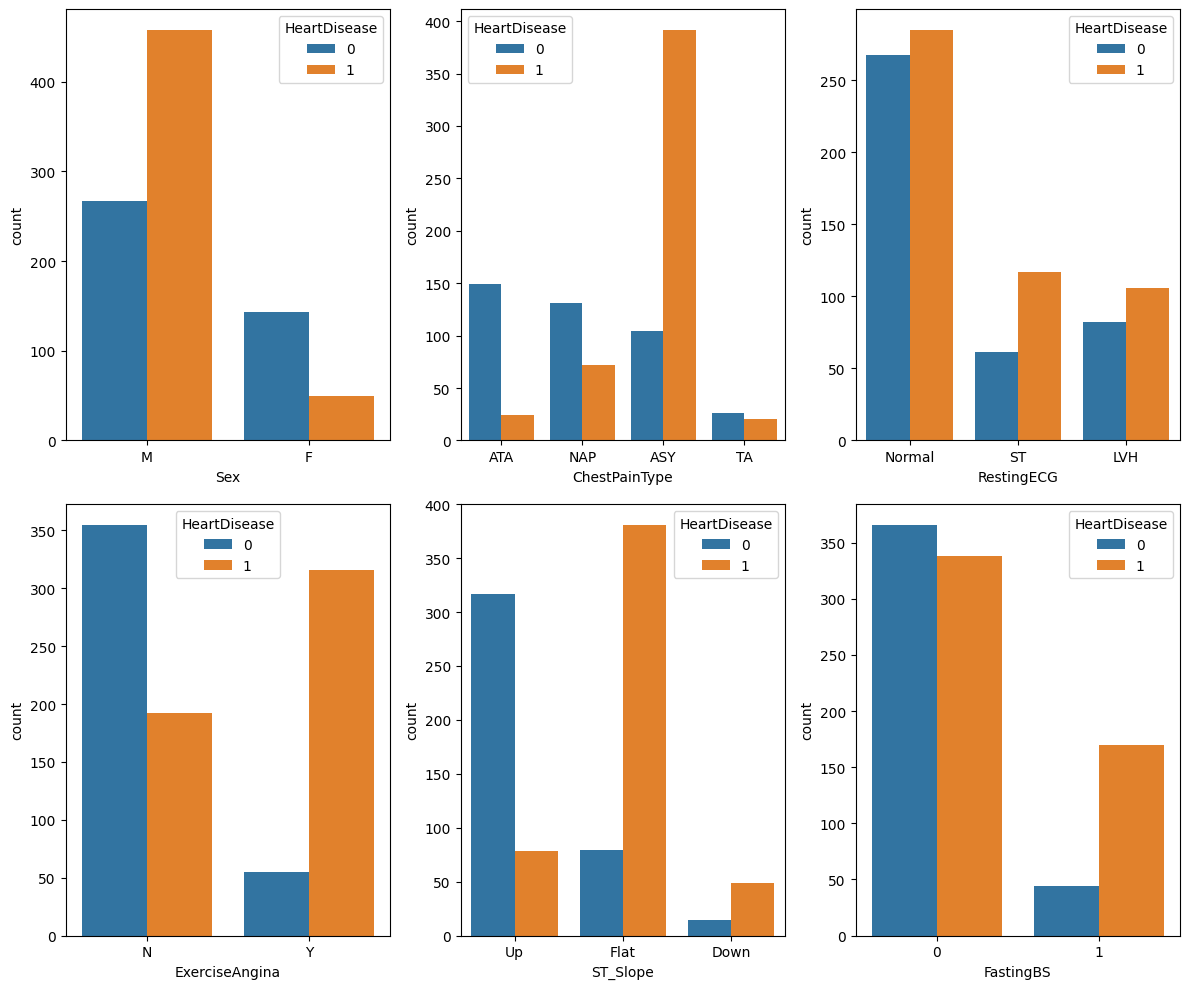

In [15]:
# Analyze the Categorical columns
fig,axis = plt.subplots(2,3,figsize = (12,10))
axis = axis.flatten()
cat_col = ['Sex', 'ChestPainType','RestingECG', 'ExerciseAngina', 'ST_Slope','FastingBS']
for i,col in enumerate(cat_col):
    sns.countplot(x=df[col],ax=axis[i],hue=df['HeartDisease'])
plt.tight_layout()

<Axes: >

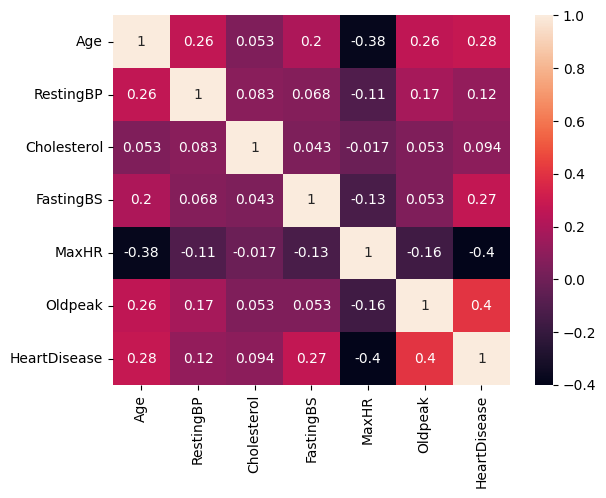

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing

In [17]:
df_encod = pd.get_dummies(df,drop_first=False)

In [18]:
df_encod = df_encod.astype(int)

In [19]:
df_encod.drop('Sex_F', axis=1, inplace=True)

In [20]:
df_encod.head(5)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1


# Standarization

In [21]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encod[numerical_cols] = scaler.fit_transform(df_encod[numerical_cols])

In [22]:
df_encod.head(5)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,0,1,0,0,1,0,1,0,0,0,1


In [33]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [35]:
X = df_encod.drop(columns='HeartDisease', axis=1)
y = df_encod['HeartDisease']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [40]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)        

In [50]:
models = {
    'log_regess' : LogisticRegression(), 
    'KNN' : KNeighborsClassifier(), 
    'NB' : GaussianNB(), 
    'DT' : DecisionTreeClassifier(), 
    'SVM' : SVC(),
    'Random Forest' : RandomForestClassifier(),
    'XGBoost' : XGBClassifier(),
}

In [51]:
output = []
for name,model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    output.append({
        'model':name,
        'Accuracy':round(acc,4),
        'f1 score':round(f1,4)
    })

In [45]:
from sklearn.ensemble import RandomForestClassifier

models['RF'] = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [46]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [47]:
from xgboost import XGBClassifier

models['XGB'] = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Tune HyperParameter

In [48]:
RandomForestClassifier(        # for Random forest
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

RandomForestClassifier(max_depth=8, min_samples_split=5, n_estimators=500,
                       random_state=42)

In [49]:
XGBClassifier(          # for XGBoost
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [53]:
output

[{'model': 'log_regess', 'Accuracy': 0.8641, 'f1 score': 0.8792},
 {'model': 'KNN', 'Accuracy': 0.8696, 'f1 score': 0.8835},
 {'model': 'NB', 'Accuracy': 0.837, 'f1 score': 0.85},
 {'model': 'DT', 'Accuracy': 0.8098, 'f1 score': 0.8187},
 {'model': 'SVM', 'Accuracy': 0.8587, 'f1 score': 0.8762},
 {'model': 'Random Forest', 'Accuracy': 0.8696, 'f1 score': 0.8835},
 {'model': 'XGBoost', 'Accuracy': 0.8913, 'f1 score': 0.9038}]

# Deploy model

In [54]:
import joblib
joblib.dump(models['XGBoost'],'XGBoost_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']